In [2]:
import numpy as np
import pandas as pd
import json
import matplotlib.pyplot as plt
import seaborn as sns

# Desciptive Analysis

### “Understanding the data before doing any conclusions.” 

In [3]:
# we will use the realtive path to read data.
df = pd.read_csv("../Data/Job_data_cleaned_1.csv")
df_trimmed = pd.read_csv("../Data/Job_Data_Trimmed.csv")

In [4]:
df.head()

,Job Type,salary_minimum,salary_maximum,salary_band,salary_range,qualification_level,sector,role_category
0,Government,63000.0,63000.0,Medium,0.0,undergraduate,Banking,Officer
1,Government,25000.0,25000.0,Low,0.0,undergraduate,Government General,Associate
2,Government,30000.0,60000.0,Medium,30000.0,undergraduate,PSU,Other
3,Government,57700.0,182400.0,Medium,124700.0,postgraduate,Government Admin,Academic
4,Government,25000.0,25000.0,Low,0.0,undergraduate,PSU,Engineer


In [7]:
print(f"Shape of Original Data : {df.shape}\nShape of trimmed Data : {df_trimmed.shape}")

Shape of Original Data : (1019, 8)
Shape of trimmed Data : (652, 8)


In [13]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1019 entries, 0 to 1018
Data columns (total 8 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Job Type             1019 non-null   object 
 1   salary_minimum       658 non-null    float64
 2   salary_maximum       658 non-null    float64
 3   salary_band          658 non-null    object 
 4   salary_range         658 non-null    float64
 5   qualification_level  1019 non-null   object 
 6   sector               1019 non-null   object 
 7   role_category        1019 non-null   object 
dtypes: float64(3), object(5)
memory usage: 63.8+ KB


In [14]:
df_trimmed.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 652 entries, 0 to 651
Data columns (total 8 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Job Type             652 non-null    object 
 1   salary_minimum       652 non-null    float64
 2   salary_maximum       652 non-null    float64
 3   salary_band          652 non-null    object 
 4   salary_range         652 non-null    float64
 5   qualification_level  652 non-null    object 
 6   sector               652 non-null    object 
 7   role_category        652 non-null    object 
dtypes: float64(3), object(5)
memory usage: 40.9+ KB


## Category based Distribution Analysis

In [101]:
df["qualification_level"].value_counts()

qualification_level
undergraduate    641
postgraduate     181
other             89
diploma           46
school_level      46
doctorate         16
Name: count, dtype: int64

##### Government hiring largely targets graduate-level roles rather than highly specialized academic roles.

In [103]:
# Doctorate and postgraduate roles are concentrated in Education sector.
df["sector"].value_counts()

sector
Government General    374
Education             238
Government Admin      131
Banking               106
PSU                    65
Judiciary              34
Energy                 31
Technical/Research     24
Healthcare             16
Name: count, dtype: int64

In [104]:
df["role_category"].value_counts()

role_category
Other          351
Managerial     142
Officer        114
Assistant       92
Engineer        90
Entry Level     79
Research        65
Academic        42
Associate       36
Medical          8
Name: count, dtype: int64

In [120]:
df["salary_band"].value_counts()

salary_band
Medium       309
Low          204
High         119
Very High     26
Name: count, dtype: int64

###  Visual reresentation of the data

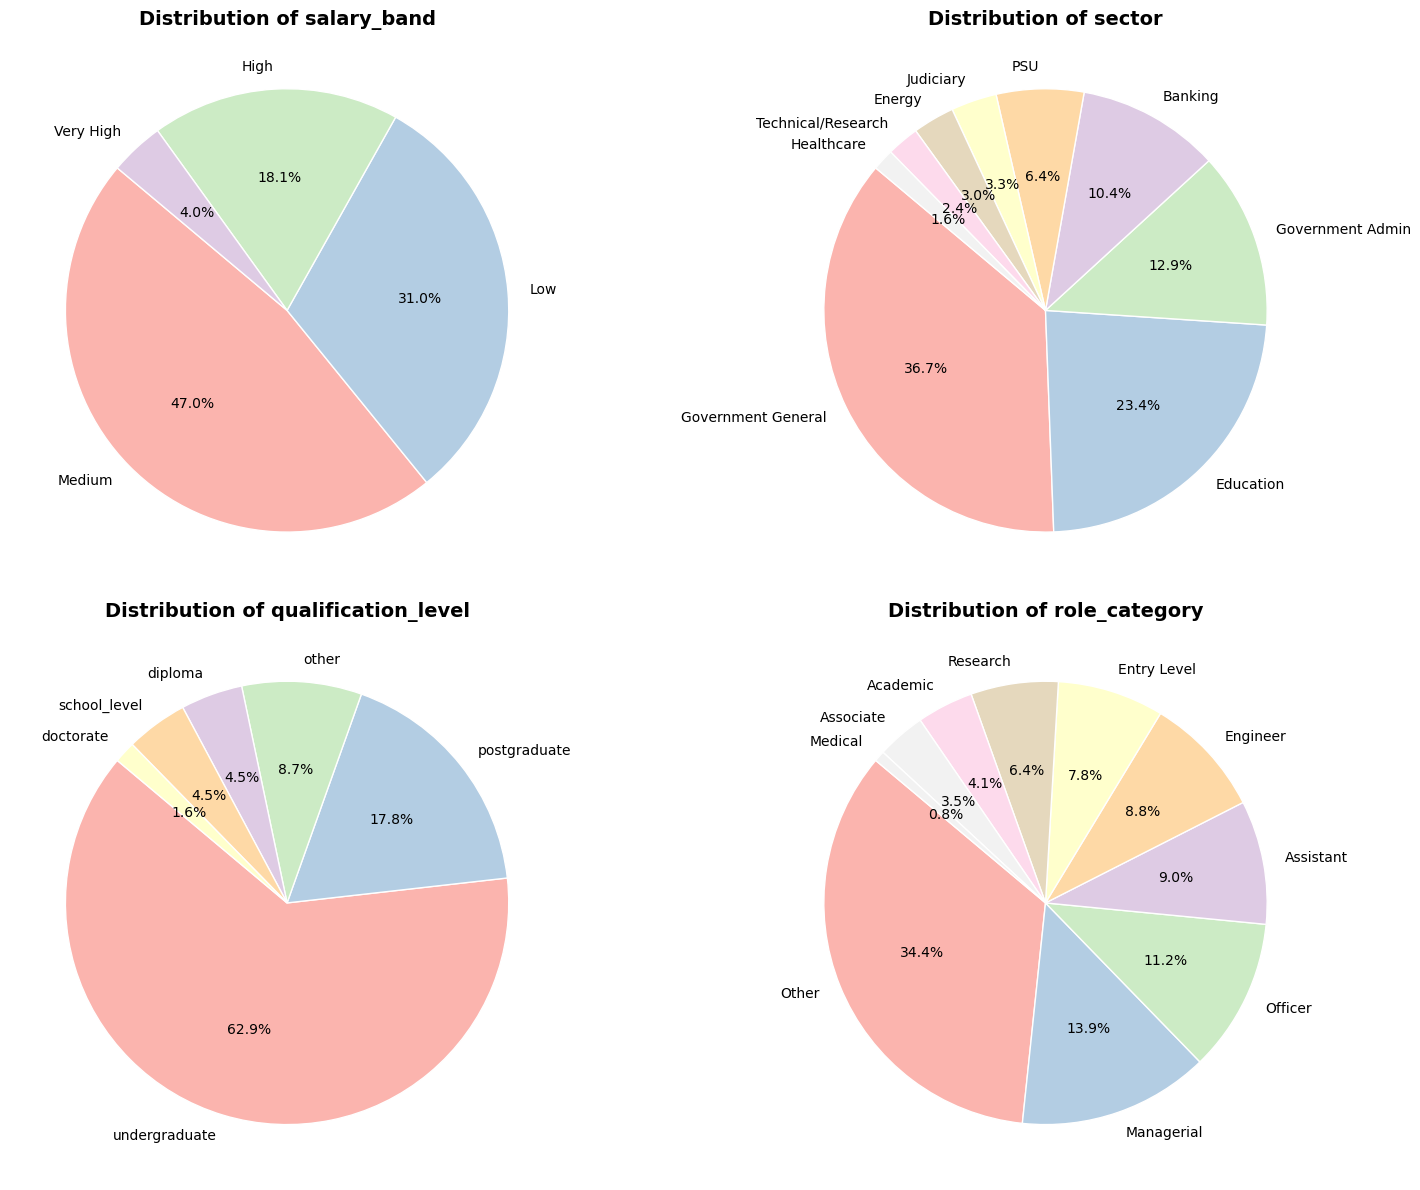

In [119]:
cat_cols = ['salary_band','qualification_level','sector','role_category']

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
in_1 = [0,1,0,1]
in_2 = [0,0,1,1]

for i, col in enumerate(cat_cols):
    counts = df[col].value_counts()
    # Gpt Code
    axes[in_1[i],in_2[i]].pie(counts, labels=counts.index, autopct='%1.1f%%', startangle=140, 
                colors=plt.cm.Pastel1(range(len(counts))),wedgeprops={'edgecolor': 'white'})
    
    axes[in_1[i],in_2[i]].set_title(f'Distribution of {col}', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

# Trimmed Data Analysis

## Numerical Data analysis

### Salary Data Analysis

In [123]:
df_trimmed["salary_minimum"]

0       63,000
1       25,000
2       30,000
3       57,700
4       25,000
         ...  
996     44,900
999     31,000
1000    37,000
1005    78,800
1018   150,000
Name: salary_minimum, Length: 652, dtype: float64

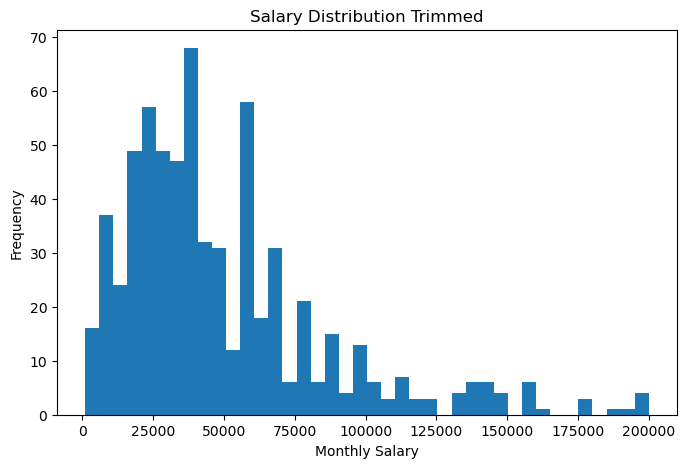

In [125]:
plt.figure(figsize=(8,5))
plt.hist(df_trimmed["salary_minimum"], bins=40)
plt.xlabel("Monthly Salary")
plt.ylabel("Frequency")
plt.title("Salary Distribution Trimmed")
plt.show()

In [113]:
df_trimmed[["salary_minimum","salary_maximum","salary_range"]].describe()

,salary_minimum,salary_maximum,salary_range
count,652,652,652
mean,"49,912","79,067","29,155"
std,"36,716","66,114","52,131"
min,"1,000","1,000",0
25%,"25,000","30,000",0
50%,"40,000","56,050",0
75%,"64,820","120,000","33,333"
max,"200,000","500,000","415,000"


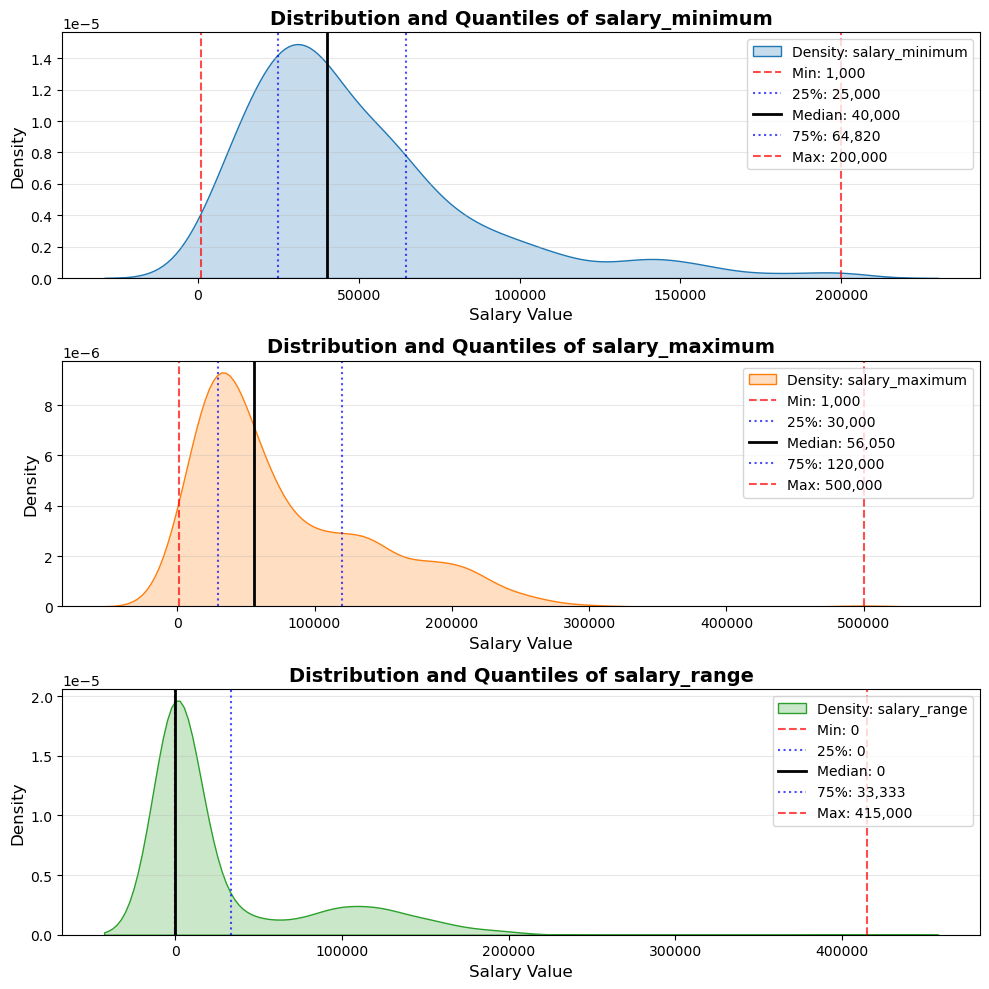

In [126]:
# 2. Define the columns we want to visualize
cols = ['salary_minimum', 'salary_maximum', 'salary_range']

# Plotting of the data
fig, axes = plt.subplots(3, 1, figsize=(10, 10))
colors = ['#1f77b4', '#ff7f0e', '#2ca02c'] # Blue, Orange, Green

for i, col in enumerate(cols):
    sns.kdeplot(df_trimmed[col], ax=axes[i], fill=True, color=colors[i], label=f'Density: {col}')
    
    Min = df_trimmed[col].min()
    q1 = df_trimmed[col].quantile(0.25)
    q2 = df_trimmed[col].quantile(0.5)
    q3 = df_trimmed[col].quantile(0.75)
    Max = df_trimmed[col].max()
    metrics = {"Min":Min,"25%":q1,"50%":q2,"75%":q3,"Max":Max}

    axes[i].axvline(metrics['Min'], color='red', linestyle='--', alpha=0.7, label=f"Min: {metrics['Min']:,.0f}")
    axes[i].axvline(metrics['25%'], color='blue', linestyle=':', alpha=0.7, label=f"25%: {metrics['25%']:,.0f}")
    axes[i].axvline(metrics['50%'], color='black', linestyle='-', linewidth=2, label=f"Median: {metrics['50%']:,.0f}")
    axes[i].axvline(metrics['75%'], color='blue', linestyle=':', alpha=0.7, label=f"75%: {metrics['75%']:,.0f}")
    axes[i].axvline(metrics['Max'], color='red', linestyle='--', alpha=0.7, label=f"Max: {metrics['Max']:,.0f}")
    
    axes[i].set_title(f'Distribution and Quantiles of {col}', fontsize=14, fontweight='bold')
    axes[i].set_xlabel('Salary Value', fontsize=12)
    axes[i].set_ylabel('Density', fontsize=12)
    axes[i].legend(loc='upper right', fontsize=10)
    axes[i].grid(axis='y', alpha=0.3)

# Adjust layout to prevent overlapping labels
plt.tight_layout()
plt.show()

# Actual Data understanding

In [10]:
df["salary_minimum"]

0        63000.0
1        25000.0
2        30000.0
3        57700.0
4        25000.0
          ...   
1014         NaN
1015         NaN
1016         NaN
1017         NaN
1018    150000.0
Name: salary_minimum, Length: 1019, dtype: float64

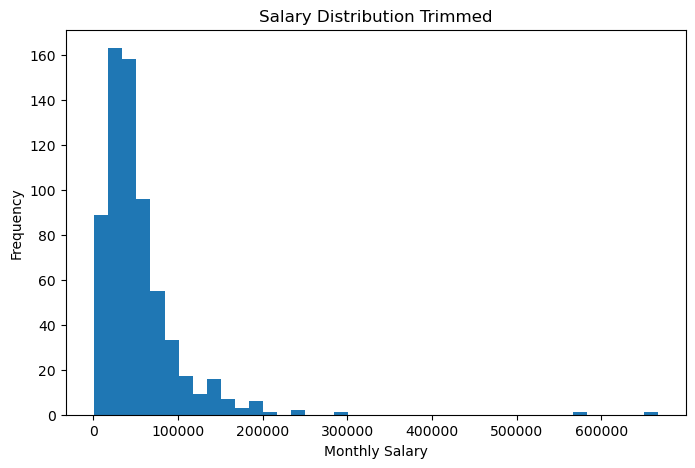

In [11]:
plt.figure(figsize=(8,5))
plt.hist(df["salary_minimum"], bins=40)
plt.xlabel("Monthly Salary")
plt.ylabel("Frequency")
plt.title("Salary Distribution Trimmed")
plt.show()

In [12]:
df[["salary_minimum","salary_maximum","salary_range"]].describe()

,salary_minimum,salary_maximum,salary_range
count,658.000000,658.000000,658.000000
mean,52878.018617,81767.422239,28889.403622
std,50885.880819,73626.397690,51966.207805
min,1000.000000,1000.000000,0.000000
25%,25000.000000,30640.000000,0.000000
50%,40000.000000,56100.000000,0.000000
75%,65000.000000,120940.000000,32250.000000
max,666666.666667,666666.666667,415000.000000


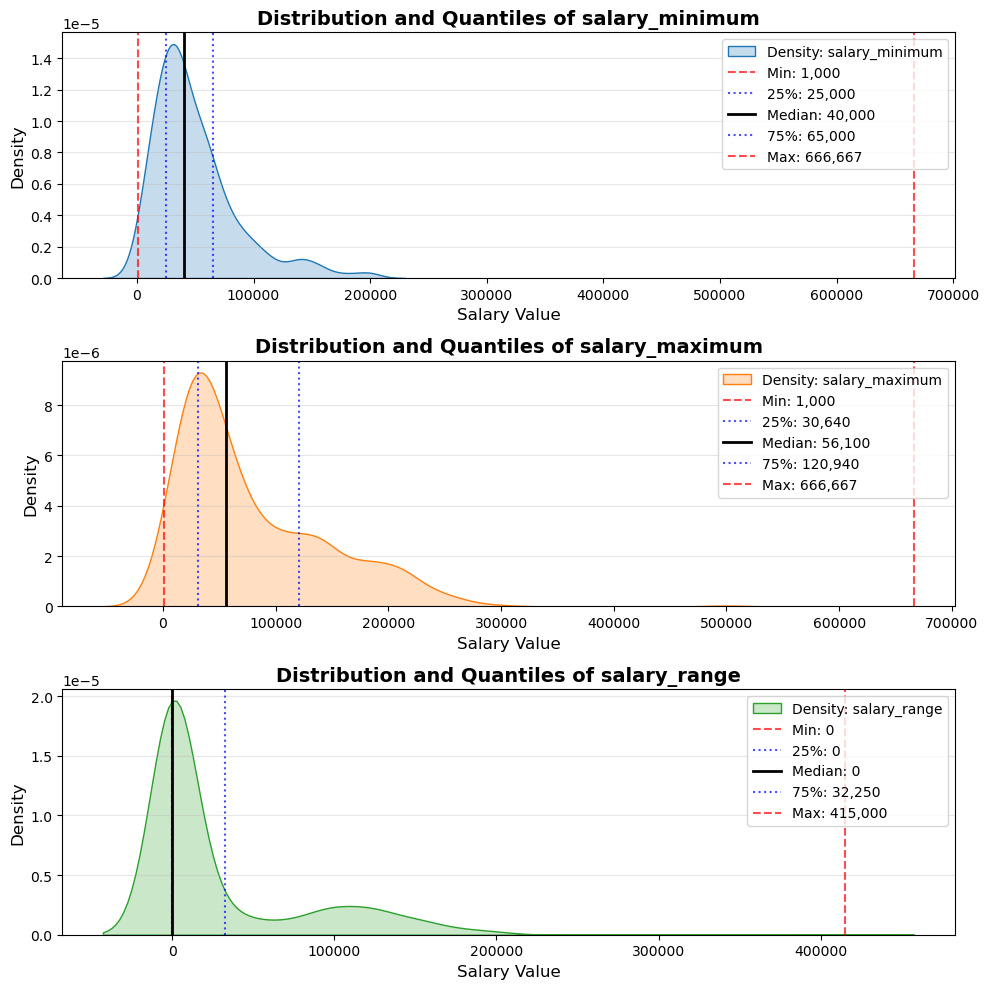

In [8]:
# 2. Define the columns we want to visualize
cols = ['salary_minimum', 'salary_maximum', 'salary_range']

# Plotting of the data
fig, axes = plt.subplots(3, 1, figsize=(10, 10))
colors = ['#1f77b4', '#ff7f0e', '#2ca02c'] # Blue, Orange, Green

for i, col in enumerate(cols):
    sns.kdeplot(df_trimmed[col], ax=axes[i], fill=True, color=colors[i], label=f'Density: {col}')
    
    Min = df[col].min()
    q1 = df[col].quantile(0.25)
    q2 = df[col].quantile(0.5)
    q3 = df[col].quantile(0.75)
    Max = df[col].max()
    metrics = {"Min":Min,"25%":q1,"50%":q2,"75%":q3,"Max":Max}

    axes[i].axvline(metrics['Min'], color='red', linestyle='--', alpha=0.7, label=f"Min: {metrics['Min']:,.0f}")
    axes[i].axvline(metrics['25%'], color='blue', linestyle=':', alpha=0.7, label=f"25%: {metrics['25%']:,.0f}")
    axes[i].axvline(metrics['50%'], color='black', linestyle='-', linewidth=2, label=f"Median: {metrics['50%']:,.0f}")
    axes[i].axvline(metrics['75%'], color='blue', linestyle=':', alpha=0.7, label=f"75%: {metrics['75%']:,.0f}")
    axes[i].axvline(metrics['Max'], color='red', linestyle='--', alpha=0.7, label=f"Max: {metrics['Max']:,.0f}")
    
    axes[i].set_title(f'Distribution and Quantiles of {col}', fontsize=14, fontweight='bold')
    axes[i].set_xlabel('Salary Value', fontsize=12)
    axes[i].set_ylabel('Density', fontsize=12)
    axes[i].legend(loc='upper right', fontsize=10)
    axes[i].grid(axis='y', alpha=0.3)

# Adjust layout to prevent overlapping labels
plt.tight_layout()
plt.show()

## Insights